In [1]:
import duckdb

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from duckdb.duckdb import DuckDBPyConnection
from pandas import DataFrame

bronze_conn = duckdb.connect('bronze_db')
prata_conn = duckdb.connect('prata_db')
ouro_conn = duckdb.connect('ouro_db')
modelling_conn = duckdb.connect('modelling_db')
final_conn = duckdb.connect('final_db')

def sql(
    query:str,
    conn:DuckDBPyConnection
) -> DataFrame:
    """
    Executa uma consulta SQL em uma conexão de banco duckDb e retorna o resultado em um dataframe Pandas.

    Parâmetros
    ----------

    query (str)
        Query SQL a ser realizada no banco
    
    conn (DuckDBPyConnection)
        Conexão com banco DB em que a consulta será realizada
    
    Returns
    ----------

    DataFrame: Dataframe do Pandas com o resultado da consulta SQL realizada

    """
    
    df = conn.execute(query).fetch_df()
    return df

In [2]:
sql("SHOW TABLES",final_conn)

,name
0,abt_base
1,tb_validacao_modelo_1_1
2,tb_validacao_modelo_1_2
3,tb_validacao_modelo_1_3
4,tb_validacao_modelo_1_4
5,tb_validacao_modelo_2_1
6,tb_validacao_modelo_2_2
7,tb_validacao_modelo_2_3
8,tb_validacao_modelo_2_4
9,tb_validacao_modelo_3_1


In [26]:
sql("SHOW TABLES",modelling_conn)

,name
0,abt_estacoes
1,abt_estacoes_3_vizinhas
2,abt_estacoes_5_vizinhas
3,abt_estacoes_vizinhas
4,abt_produtos
5,fato_estacoes_fila_P_1


In [3]:
sql("SHOW TABLES",ouro_conn)

,name
0,abt_estacoes
1,abt_produtos
2,dim_estacoes
3,fato_estacoes_base_fila_prioridade
4,fato_estacoes_correlacao
5,fato_estacoes_distancia
6,fato_estacoes_intersecao
7,fato_estacoes_latlon_produtos_df
8,fato_estacoes_precipitacao
9,fato_estacoes_temperatura_maxima


# 4.1.1) Panorama das estações meteorológicas

In [2]:
df_abt_base = sql("""
SELECT
    *
FROM abt_base
""",
conn=final_conn)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
df_dim_estacoes = sql(
"""
SELECT
    *
FROM dim_estacoes
""",ouro_conn)

df_dim_estacoes = df_abt_base[['id_estacao']].drop_duplicates() \
    .merge(df_dim_estacoes,on=['id_estacao'],how='inner')

In [6]:
df_dim_estacoes['id_estacao'].nunique()

3990

In [7]:
df_dim_estacoes.groupby('nm_instituicao')['id_estacao'].nunique()

nm_instituicao
Agência Nacional de Águas                                           1816
Centro Nacional de Monitoramento e Alertas de Desastres Naturais    1605
Centro de Desenvolvimento do Vale do Paranapanema                      5
Companhia Energética de Minas Gerais                                 135
Cooperativa Regional de Cafeicultores em Guaxupé Ltda                 14
Fazenda Paineiras (Instituição Particular Goiás)                      13
Instituto Agronômico de Campinas                                      93
Instituto Nacional de Meteorologia                                   270
Instituto Tecnológico SIMEPAR                                          6
Sistema Alerta Rio                                                    33
Name: id_estacao, dtype: int64

In [8]:
total_estacoes_global = df_dim_estacoes['id_estacao'].nunique()
df_estacoes_variaveis_contagem = df_dim_estacoes.groupby('nm_variavel')['id_estacao'].nunique().sort_values(ascending=False).reset_index(name='contagem')
df_estacoes_variaveis_contagem['percentual'] = (df_estacoes_variaveis_contagem['contagem'] / total_estacoes_global) * 100

print(df_estacoes_variaveis_contagem)

                   nm_variavel  contagem  percentual
0                 precipitacao      3990  100.000000
1           temperaturaarmedia       569   14.260652
2          temperaturaarminima       569   14.260652
3          temperaturaarmaxima       569   14.260652
4        umidaderelativaminima       452   11.328321
5        umidaderelativamaxima       452   11.328321
6     pressaoatmosfericaminima       438   10.977444
7     pressaoatmosfericamaxima       438   10.977444
8   evapotranspiracaopotencial       362    9.072682
9      velocidadeventomaximo2m       319    7.994987
10           radiacaosolarreal       309    7.744361
11        umidaderelativamedia       303    7.593985
12     pressaoatmosfericamedia       303    7.593985
13     velocidadeventomedio10m       270    6.766917
14      velocidadeventomedio2m       270    6.766917
15           evaporimetropiche       270    6.766917
16          pontoorvalhominimo       270    6.766917
17           pontoorvalhomedio       270    6.

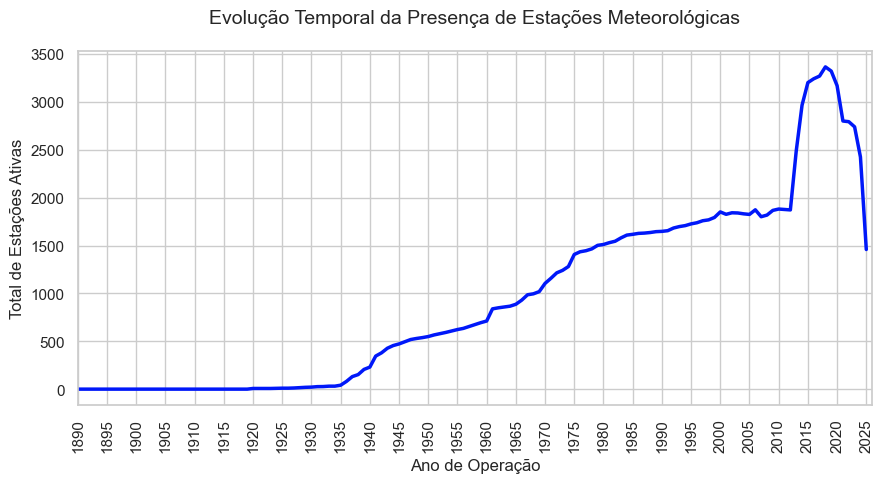

In [9]:
df_dim_estacoes_inicio_fim = df_dim_estacoes.groupby('id_estacao',as_index=False).agg(
    dt_inicio = ('dt_inicio_dados_variavel','min'),
    dt_fim = ('dt_fim_dados_variavel','max')
)

# 1. Converter colunas para datetime
df_dim_estacoes_inicio_fim['dt_inicio'] = pd.to_datetime(df_dim_estacoes_inicio_fim['dt_inicio'])
df_dim_estacoes_inicio_fim['dt_fim'] = pd.to_datetime(df_dim_estacoes_inicio_fim['dt_fim'])

# 2. Tratar estações que ainda estão ativas (dt_fim nulo)
# Substituímos o valor nulo pelo ano atual para que elas contem no gráfico
ano_atual = pd.Timestamp.now().year
df_temp = df_dim_estacoes_inicio_fim.copy()
df_temp['dt_fim_calc'] = df_temp['dt_fim'].fillna(pd.Timestamp(f'{ano_atual}-12-31'))

# 3. Definir o intervalo de anos que queremos analisar
ano_min = int(df_temp['dt_inicio'].dt.year.min())
ano_max = int(df_temp['dt_fim_calc'].dt.year.max())
anos = range(ano_min, ano_max + 1)

# 4. Contar estações ativas para cada ano
contagem_por_ano = []
for ano in anos:
    # Condição: ano de início <= ano analisado E ano de fim >= ano analisado
    ativas = df_temp[
        (df_temp['dt_inicio'].dt.year <= ano) & 
        (df_temp['dt_fim_calc'].dt.year >= ano)
    ]
    contagem_por_ano.append({'ano': ano, 'qtd_estacoes': ativas['id_estacao'].nunique()})

df_evolucao = pd.DataFrame(contagem_por_ano)

# 1. Configuração visual do Seaborn
sns.set_theme(style="whitegrid") # Define o fundo com grades suaves
plt.figure(figsize=(9, 5))

# 2. Criar o gráfico de linha
# markers=True adiciona pontos em cada ano para facilitar a leitura
g = sns.lineplot(
    data=df_evolucao, 
    x='ano', 
    y='qtd_estacoes', 
    linewidth=2.5, 
    color='#0018F9'
)

# 3. Ajustes de títulos e eixos
plt.title('Evolução Temporal da Presença de Estações Meteorológicas', fontsize=14, pad=20)
plt.xlabel('Ano de Operação', fontsize=12)
plt.ylabel('Total de Estações Ativas', fontsize=12)

# Garante que o eixo X mostre os anos de forma legível
plt.xticks(df_evolucao['ano'][::5], rotation=90)
plt.xlim(1890,2026)

# Ajuste final para não cortar as legendas
plt.tight_layout()
plt.show()

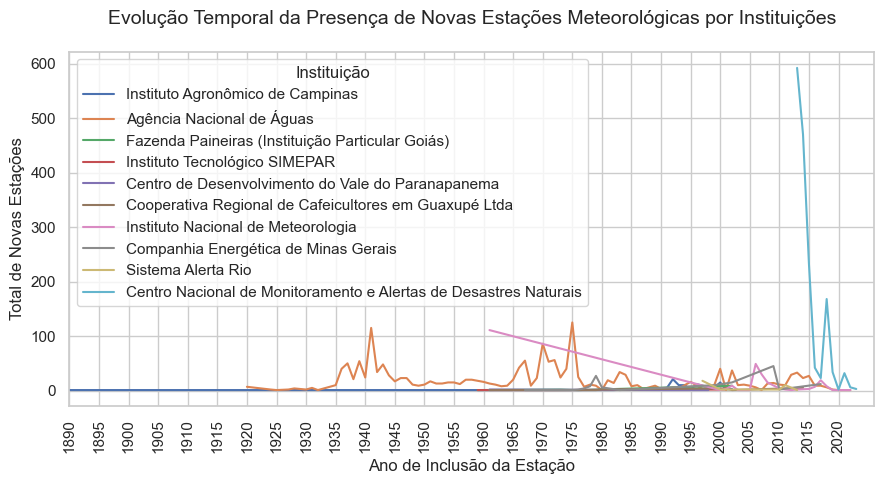

In [10]:
df_dim_estacoes_analise_datas_instituicoes = df_dim_estacoes.groupby(['id_estacao','nm_instituicao'],as_index=False).agg(
    dt_inicio = ('dt_inicio_dados_variavel','min'),
    dt_fim = ('dt_fim_dados_variavel','max')
)
df_dim_estacoes_analise_datas_instituicoes['dt_inicio_year'] = df_dim_estacoes_analise_datas_instituicoes['dt_inicio'].dt.year
df_dim_estacoes_analise_datas_instituicoes['dt_fim_year'] = df_dim_estacoes_analise_datas_instituicoes['dt_fim'].dt.year

df_dim_estacoes_analise_datas_instituicoes = df_dim_estacoes_analise_datas_instituicoes.groupby(['dt_inicio_year','nm_instituicao'],as_index=False).agg(
    count_estacoes = ('id_estacao','nunique')
)

df_dim_estacoes_analise_datas_instituicoes = df_dim_estacoes_analise_datas_instituicoes.rename(columns={
    'count_estacoes':'Contagem de Novas Estações',
    'nm_instituicao':'Instituição',
    'dt_inicio_year':'Ano'
})

sns.set_theme(style="whitegrid") # Define o fundo com grades suaves
plt.figure(figsize=(9,5))

g = sns.lineplot(
    data=df_dim_estacoes_analise_datas_instituicoes,
    x='Ano',
    y='Contagem de Novas Estações',
    hue='Instituição'
    )

plt.title('Evolução Temporal da Presença de Novas Estações Meteorológicas por Instituições', fontsize=14, pad=20)
plt.xlabel('Ano de Inclusão da Estação', fontsize=12)
plt.ylabel('Total de Novas Estações', fontsize=12)

# Garante que o eixo X mostre os anos de forma legível
ano_min = df_dim_estacoes_analise_datas_instituicoes['Ano'].min()
ano_max = df_dim_estacoes_analise_datas_instituicoes['Ano'].max()
ticks_5_em_5 = [ano for ano in range(ano_min, ano_max + 1) if ano % 5 == 0]

plt.xticks(ticks_5_em_5, rotation=90)
plt.xlim(1890,2026)

# Ajuste final para não cortar as legendas
plt.tight_layout()
plt.show()

In [11]:
df_abt_base['dt_medicao'].min()

Timestamp('2000-01-01 00:00:00')

# 4.1.2) Medições de precipitação em estações meteorológicas

In [12]:
n_zero_rain = len(df_abt_base.loc[df_abt_base['vl_precipitacao']==0])
n_total = len(df_abt_base)

print(n_zero_rain/n_total)

0.6777232932087026


In [13]:
n_less_than_1_mm = len(df_abt_base.loc[df_abt_base['vl_precipitacao']<1])
n_total = len(df_abt_base)

print(n_less_than_1_mm/n_total)

0.7409024600064935


In [14]:
n_more_than_10_mm = len(df_abt_base.loc[df_abt_base['vl_precipitacao']>=10])
n_total = len(df_abt_base)

print(n_more_than_10_mm/n_total)

0.11721175638763798


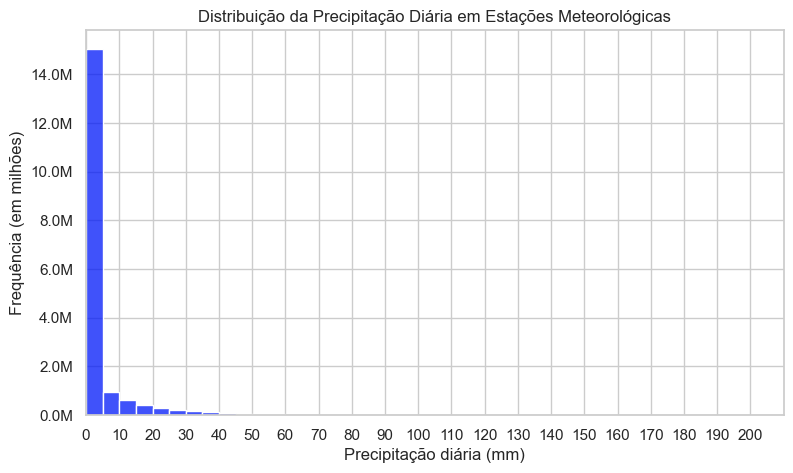

In [15]:
sns.set_theme(style="whitegrid") # Define o fundo com grades suaves
plt.figure(figsize=(9,5))
g = sns.histplot(x=df_abt_base['vl_precipitacao'],binwidth=5,color='#0018F9')

plt.title('Distribuição da Precipitação Diária em Estações Meteorológicas')
plt.xlabel('Precipitação diária (mm)', fontsize=12)
plt.ylabel('Frequência (em milhões)', fontsize=12)

chuva_min = df_abt_base['vl_precipitacao'].min()
chuva_max = df_abt_base['vl_precipitacao'].max()
ticks_10_em_10 = [ano for ano in range(int(chuva_min), int(chuva_max) + 1) if ano % 10 == 0]

plt.xticks(ticks_10_em_10, rotation=0)
plt.xlim(0,chuva_max+10)

def millions(x, pos):
    return f'{x*1e-6:.1f}M' # Exibe 1 casa decimal + 'M'

formatter = ticker.FuncFormatter(millions)
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

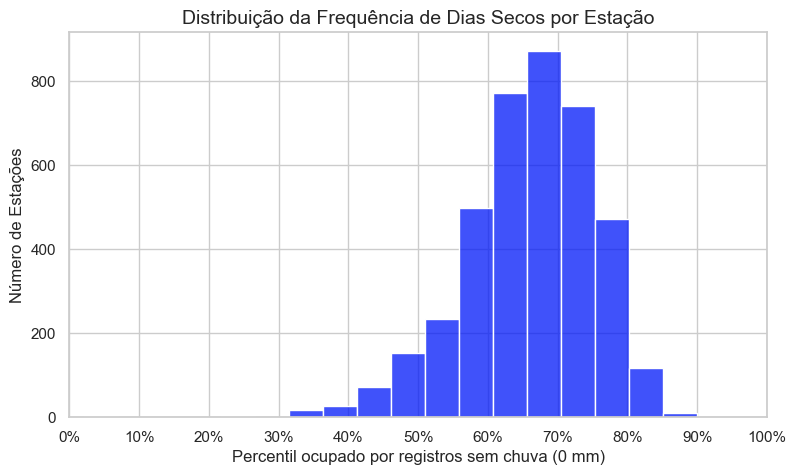

In [16]:
# 1. Calcula a proporção de zeros (percentil do limite da chuva zero) por estação
df_zero_perc = (
    df_abt_base.groupby('id_estacao')['vl_precipitacao']
    .apply(lambda x: (x == 0).mean()) # Média de um booleano = proporção
    .reset_index(name='percentil_zero')
)

# 2. Configuração visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))

# 3. Plot do Histograma
g = sns.histplot(
    data=df_zero_perc, 
    x='percentil_zero', 
    binwidth=0.05,  
    color='#0018F9'
)

# 4. Ajustes de títulos e eixos (padrão acadêmico)
plt.title('Distribuição da Frequência de Dias Secos por Estação', fontsize=14)
plt.xlabel('Percentil ocupado por registros sem chuva (0 mm)', fontsize=12)
plt.ylabel('Número de Estações', fontsize=12)

plt.xticks([0.01*x for x in range(0,101,10)], rotation=0)
plt.xlim(0,1)
# Transforma o eixo X em porcentagem (0.8 -> 80%)
g.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))

plt.show()

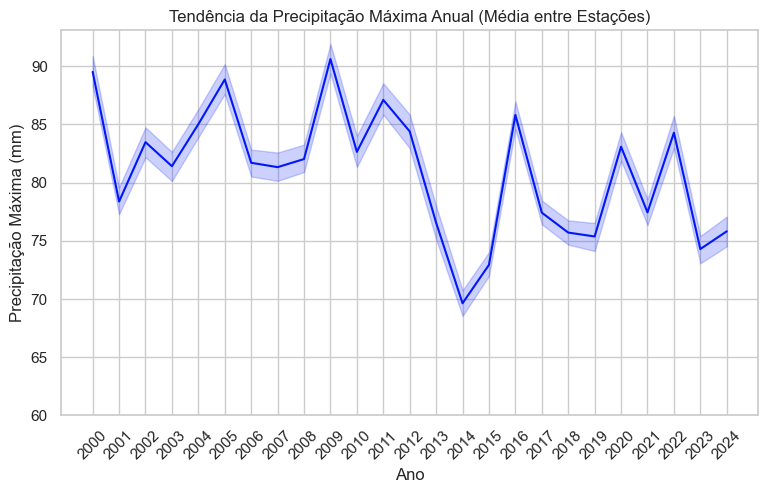

In [17]:
df_max_por_estacao_por_ano = df_abt_base[['id_estacao','dt_medicao','vl_precipitacao']].copy()
df_max_por_estacao_por_ano['dt_medicao_ano'] = df_max_por_estacao_por_ano['dt_medicao'].dt.year

df_max_por_estacao_por_ano = df_max_por_estacao_por_ano.groupby(['id_estacao','dt_medicao_ano'],as_index=False)['vl_precipitacao'].max()

plt.figure(figsize=(9,5))
sns.lineplot(data=df_max_por_estacao_por_ano, x='dt_medicao_ano', y='vl_precipitacao', color='#0018F9',errorbar='ci')

plt.title('Tendência da Precipitação Máxima Anual (Média entre Estações)')
plt.xlabel('Ano')
plt.ylabel('Precipitação Máxima (mm)')
plt.xticks(range(2000,2025),rotation=45)
plt.yticks([x for x in range(60,91) if x%5==0])

plt.show()

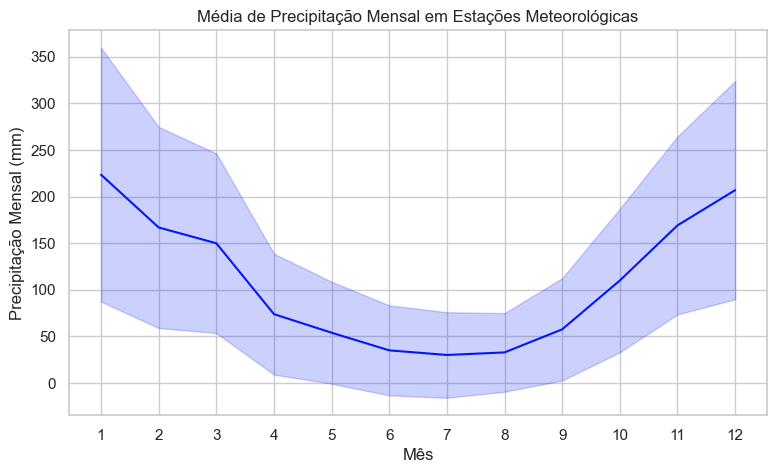

In [18]:
df_chuva_mensal = df_abt_base.copy()
df_chuva_mensal['dt_medicao_mes'] = df_chuva_mensal['dt_medicao'].dt.month.astype(str)
df_chuva_mensal['dt_medicao_ano'] = df_chuva_mensal['dt_medicao'].dt.year.astype(str)
df_chuva_mensal['dt_medicao_trunc'] = pd.to_datetime(df_chuva_mensal['dt_medicao_ano'] + '-' + df_chuva_mensal['dt_medicao_mes'] + '-' + '01')

df_chuva_mensal = df_chuva_mensal \
    .groupby(['id_estacao','dt_medicao_trunc','dt_medicao_mes'],as_index=False).agg(
        vl_precipitacao_mensal = ('vl_precipitacao','sum')
    )

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))

sns.lineplot(
    data=df_chuva_mensal,
    x='dt_medicao_mes',
    y='vl_precipitacao_mensal',
    errorbar='sd',
    color='#0018F9'
)

plt.title('Média de Precipitação Mensal em Estações Meteorológicas')
plt.xlabel('Mês')
plt.ylabel('Precipitação Mensal (mm)')
# plt.yticks([x for x in range(60,91) if x%5==0])
plt.show()

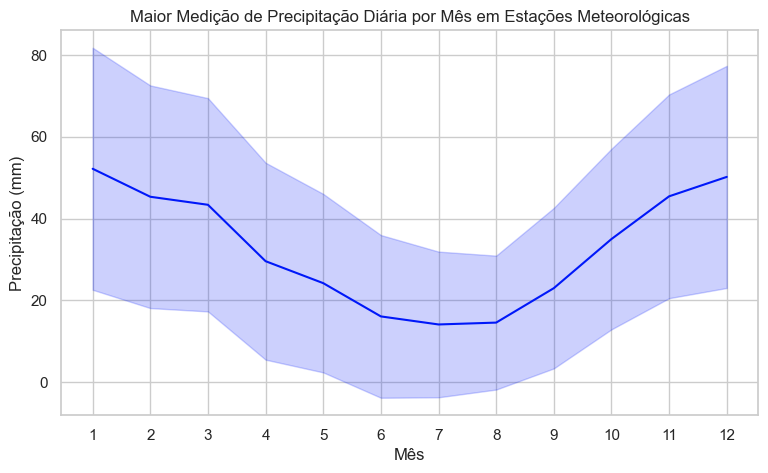

In [19]:

df_chuva_mensal_max = df_abt_base.copy()
df_chuva_mensal_max['dt_medicao_mes'] = df_chuva_mensal_max['dt_medicao'].dt.month.astype(str)
df_chuva_mensal_max['dt_medicao_ano'] = df_chuva_mensal_max['dt_medicao'].dt.year.astype(str)
df_chuva_mensal_max['dt_medicao_trunc'] = pd.to_datetime(df_chuva_mensal_max['dt_medicao_ano'] + '-' + df_chuva_mensal_max['dt_medicao_mes'] + '-' + '01')

df_chuva_mensal_max = df_chuva_mensal_max \
    .groupby(['id_estacao','dt_medicao_trunc','dt_medicao_mes'],as_index=False).agg(
        vl_precipitacao_mensal_max = ('vl_precipitacao','max')
    )

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))

sns.lineplot(
    data=df_chuva_mensal_max,
    x='dt_medicao_mes',
    y='vl_precipitacao_mensal_max',
    errorbar='sd',
    color='#0018F9'
)

plt.title('Maior Medição de Precipitação Diária por Mês em Estações Meteorológicas')
plt.xlabel('Mês')
plt.ylabel('Precipitação (mm)')
# plt.yticks([x for x in range(60,91) if x%5==0])
plt.show()

In [86]:
df_abt_base.columns

Index(['id_estacao', 'latitude', 'longitude', 'vl_declividade', 'vl_altitude',
       'vl_distancia_oceano', 'vl_aspecto_relevo', 'dt_medicao',
       'vl_precipitacao', 'vl_temperatura_maxima', 'vl_temperatura_media',
       'vl_temperatura_minima', 'vl_umidade_relativa_maxima',
       'vl_umidade_relativa_media', 'vl_umidade_relativa_minima',
       'vl_velocidade_vento_2m_maxima', 'vl_velocidade_vento_2m_media',
       'vl_velocidade_vento_10m_media', 'vl_precipitacao_chirps',
       'vl_precipitacao_cpc', 'vl_temperatura_maxima_cpc',
       'vl_temperatura_minima_cpc', 'vl_precipitacao_gpm_final_run',
       'vl_precipitacao_gpm_late_run', 'vl_precipitacao_power',
       'vl_temperatura_maxima_2m_K_power', 'vl_temperatura_media_2m_K_power',
       'vl_temperatura_minima_2m_K_power', 'vl_umidade_relativa_2m_power',
       'vl_pressao_nivel_superficie_power', 'vl_irradiancia_allsky_power',
       'vl_direcao_vento_10m_power', 'vl_direcao_vento_2m_power',
       'vl_temperatura_orvalh

# 4.1.3) Método das Filas de Prioridade

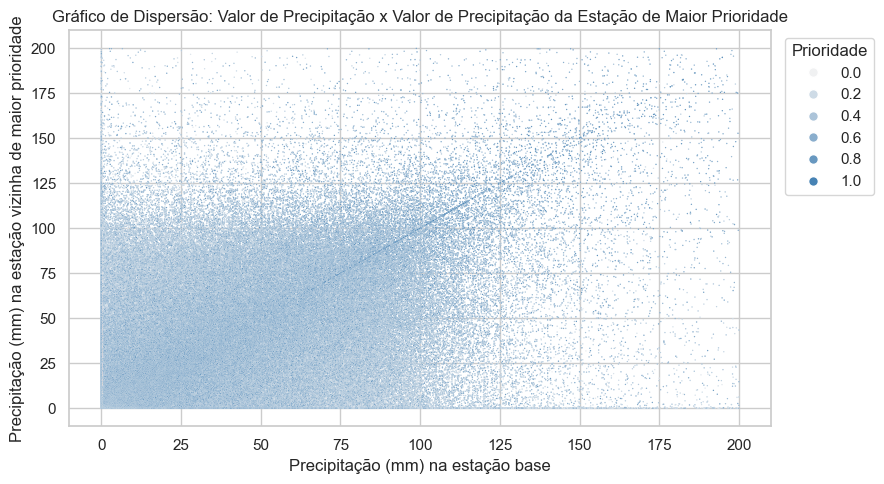

In [18]:
import numpy as np
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.light_palette("steelblue", as_cmap=True)

sns.scatterplot(
    data=df_abt_base,
    x='vl_precipitacao',
    y='vl_precipitacao_vizinha_1',
    hue='vl_prioridade_vizinha_1',
    palette=palette,
    s=1,
    ax=ax,
    legend=False
)

norm = plt.Normalize(0, 1)
legend_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=palette(norm(p)),
        markersize=7,
        label=f'{p:.1f}'
    )
    for p in legend_bins
]

ax.legend(
    handles=legend_handles,
    title='Prioridade',
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

ax.set_title(
    'Gráfico de Dispersão: Valor de Precipitação x '
    'Valor de Precipitação da Estação de Maior Prioridade'
)
ax.set_xlabel('Precipitação (mm) na estação base')
ax.set_ylabel('Precipitação (mm) na estação vizinha de maior prioridade')

plt.tight_layout()
plt.show()

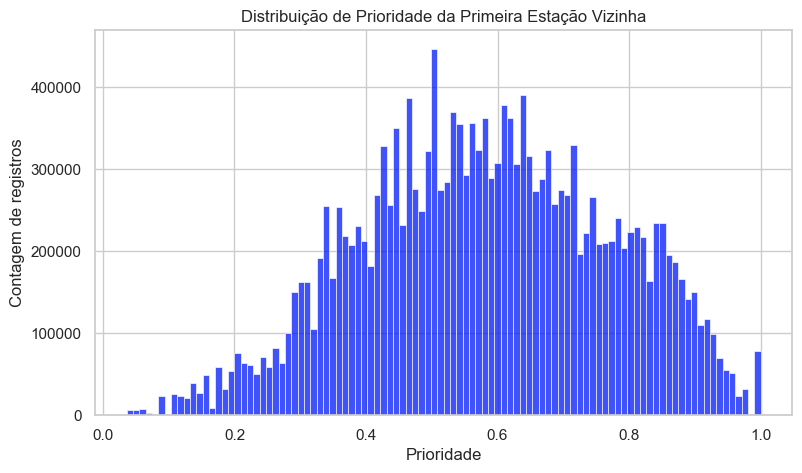

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))

sns.histplot(df_abt_base['vl_prioridade_vizinha_1'],bins=100,color='#0018F9')

plt.title('Distribuição de Prioridade da Primeira Estação Vizinha')
plt.xlabel('Prioridade')
plt.ylabel('Contagem de registros')
plt.show()



In [10]:
df_abt_base['vl_prioridade_vizinha_1'].mean()

0.5818295308801626

In [11]:
df_abt_base['vl_prioridade_vizinha_1'].std()

0.18887412141909646

In [3]:
df_abt_base[['vl_precipitacao','vl_precipitacao_vizinha_1']].corr()

,vl_precipitacao,vl_precipitacao_vizinha_1
vl_precipitacao,1.000000,0.651721
vl_precipitacao_vizinha_1,0.651721,1.000000


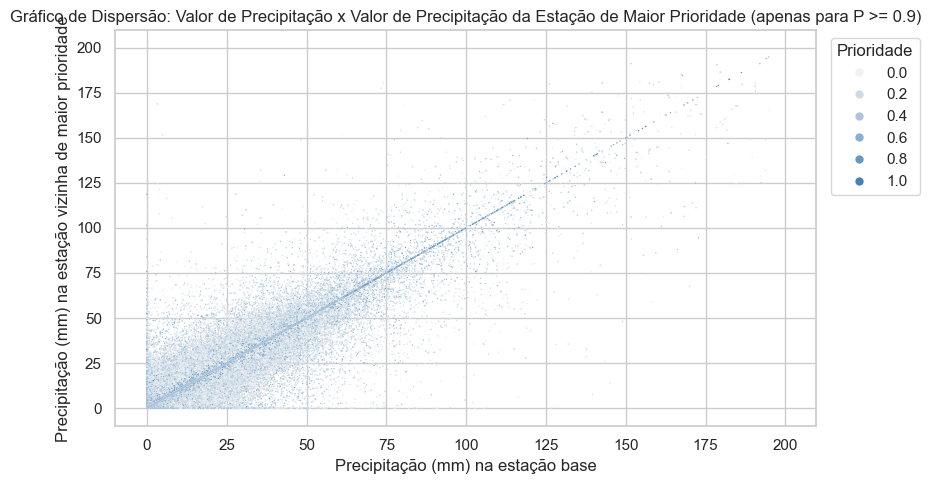

In [ ]:
import numpy as np
from matplotlib.lines import Line2D

thresh = 0.9

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.light_palette("steelblue", as_cmap=True)

sns.scatterplot(
    data=df_abt_base.loc[df_abt_base['vl_prioridade_vizinha_1']>=thresh],
    x='vl_precipitacao',
    y='vl_precipitacao_vizinha_1',
    hue='vl_prioridade_vizinha_1',
    palette=palette,
    s=1,
    ax=ax,
    legend=False
)

norm = plt.Normalize(0, 1)
legend_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=palette(norm(p)),
        markersize=7,
        label=f'{p:.1f}'
    )
    for p in legend_bins
]

ax.legend(
    handles=legend_handles,
    title='Prioridade',
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

ax.set_title(
    'Gráfico de Dispersão: Valor de Precipitação x '
    f'Valor de Precipitação da Estação de Maior Prioridade (apenas para P >= {thresh})'
)
ax.set_xlabel('Precipitação (mm) na estação base')
ax.set_ylabel('Precipitação (mm) na estação vizinha de maior prioridade')

plt.tight_layout()
plt.show()

In [5]:
df_abt_base.loc[df_abt_base['vl_prioridade_vizinha_1']>=0.9,['vl_precipitacao','vl_precipitacao_vizinha_1']].corr()

,vl_precipitacao,vl_precipitacao_vizinha_1
vl_precipitacao,1.000000,0.931096
vl_precipitacao_vizinha_1,0.931096,1.000000


In [19]:
df_abt_base['erro_abs'] = (df_abt_base['vl_precipitacao_vizinha_1']-df_abt_base['vl_precipitacao']).abs()
df_abt_base['erro_pct'] = ((df_abt_base['vl_precipitacao_vizinha_1']-df_abt_base['vl_precipitacao'])/df_abt_base['vl_precipitacao']).abs()

df_abt_base.loc[df_abt_base['vl_precipitacao']>0,['erro_abs','vl_prioridade_vizinha_1']].corr(method='spearman')

,erro_abs,vl_prioridade_vizinha_1
erro_abs,1.000000,-0.276232
vl_prioridade_vizinha_1,-0.276232,1.000000


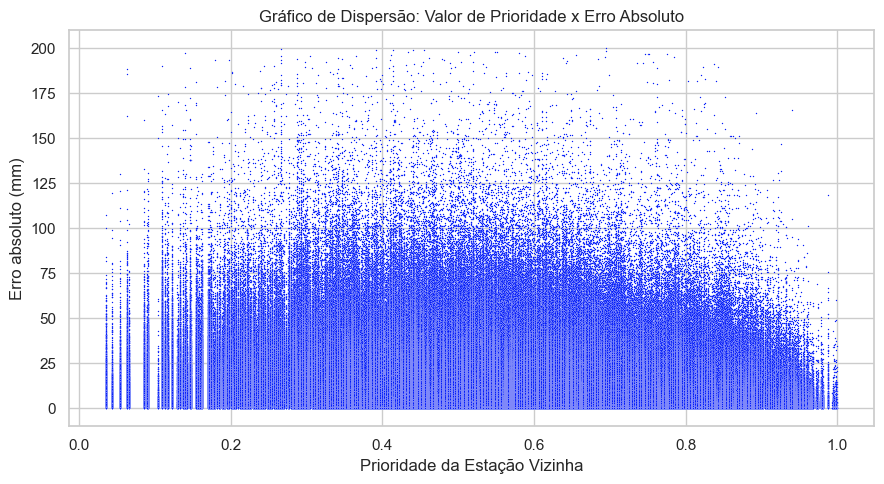

In [16]:
import numpy as np
from matplotlib.lines import Line2D

df_abt_base['erro_abs'] = (df_abt_base['vl_precipitacao_vizinha_1']-df_abt_base['vl_precipitacao']).abs()
df_abt_base['erro_pct'] = ((df_abt_base['vl_precipitacao_vizinha_1']-df_abt_base['vl_precipitacao'])/df_abt_base['vl_precipitacao']).abs()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.light_palette("steelblue", as_cmap=True)

sns.scatterplot(
    data=df_abt_base,
    x='vl_prioridade_vizinha_1',
    y='erro_abs',
    color='#0018F9',
    s=1,
    ax=ax,
    legend=False
)

ax.set_title(
    'Gráfico de Dispersão: Valor de Prioridade x '
    f'Erro Absoluto'
)
ax.set_xlabel('Prioridade da Estação Vizinha')
ax.set_ylabel('Erro absoluto (mm)')

plt.tight_layout()
plt.show()

In [21]:
def aggregate_error_by_priority_bins(
    df: pd.DataFrame,
    priority_col: str = "vl_prioridade_vizinha_1",
    error_col: str = "erro_abs",
    bin_width: float = 0.1,
) -> pd.DataFrame:
    """
    Agrega estatísticas do erro absoluto por bins da coluna de prioridade.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contendo as colunas de prioridade e erro.
    priority_col : str
        Nome da coluna de prioridade (valores entre 0 e 1).
    error_col : str
        Nome da coluna de erro absoluto.
    bin_width : float
        Largura de cada bin de prioridade.

    Returns
    -------
    pd.DataFrame
        DataFrame com bins de prioridade e estatísticas agregadas do erro.
    """
    bins = np.arange(0, 1 + bin_width, bin_width)
    labels = [f"{b:.2f}-{b + bin_width:.2f}" for b in bins[:-1]]

    df = df.copy()
    df["bin_prioridade"] = pd.cut(df[priority_col], bins=bins, labels=labels, include_lowest=True)

    return (
        df.groupby("bin_prioridade", observed=True)[error_col]
        .agg(
            media="mean",
            mediana="median",
            desvio_padrao="std",
            maximo="max",
            minimo="min",
            contagem="count",
        )
        .reset_index()
    )

df_erro_por_prioridade = aggregate_error_by_priority_bins(df_abt_base)

df_erro_por_prioridade = aggregate_error_by_priority_bins(
    df_abt_base, bin_width=0.05
)

In [23]:
df_erro_por_prioridade

,bin_prioridade,media,mediana,desvio_padrao,maximo,minimo,contagem
0,0.00-0.05,4.018103,0.0,9.918490,119.800000,0.0,6501
1,0.05-0.10,4.442890,0.0,10.797958,188.300000,0.0,38390
2,0.10-0.15,4.454154,0.0,11.132873,197.300000,0.0,120953
3,0.15-0.20,4.361772,0.0,10.639913,193.800000,0.0,191511
4,0.20-0.25,4.045574,0.0,10.062767,190.400000,0.0,326576
5,0.25-0.30,4.353984,0.0,10.639146,199.600000,0.0,497155
6,0.30-0.35,4.012163,0.0,9.846342,195.700000,0.0,875372
7,0.35-0.40,3.831278,0.0,9.482522,199.200000,0.0,1123624
8,0.40-0.45,3.636874,0.0,9.190021,199.200000,0.0,1406083
9,0.45-0.50,3.452009,0.0,8.888628,199.100000,0.0,1495005


# 4.1.4) Dados de produtos

<Axes: >

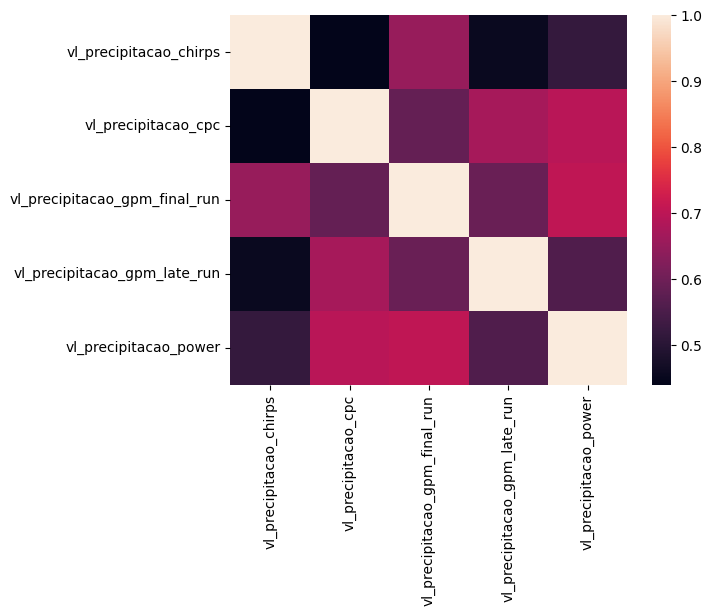

In [ ]:
precipitacao_produtos_columns = ['vl_precipitacao_chirps','vl_precipitacao_cpc','vl_precipitacao_gpm_final_run','vl_precipitacao_gpm_late_run','vl_precipitacao_power']

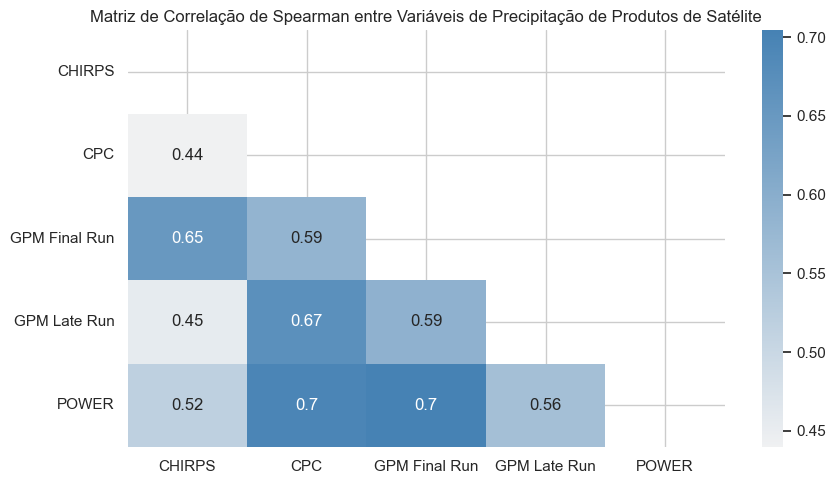

In [36]:
df_corr_produto = df_abt_base.loc[df_abt_base['vl_precipitacao_cpc']>=0,precipitacao_produtos_columns].corr(method='spearman') \
    .rename(
        columns={
            'vl_precipitacao_chirps':'CHIRPS',
            'vl_precipitacao_cpc':'CPC',
            'vl_precipitacao_gpm_final_run':'GPM Final Run',
            'vl_precipitacao_gpm_late_run':'GPM Late Run',
            'vl_precipitacao_power':'POWER'
        },
        index={
            'vl_precipitacao_chirps':'CHIRPS',
            'vl_precipitacao_cpc':'CPC',
            'vl_precipitacao_gpm_final_run':'GPM Final Run',
            'vl_precipitacao_gpm_late_run':'GPM Late Run',
            'vl_precipitacao_power':'POWER'
        }
    )

palette = sns.light_palette("steelblue", as_cmap=True)
mask = np.triu(np.ones_like(df_corr_produto, dtype=bool))

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    df_corr_produto,
    mask=mask,
    cmap=palette,
    annot=True)

ax.set_title(
    'Matriz de Correlação de Spearman entre Variáveis de Precipitação de Produtos de Satélite'
)

plt.tight_layout()
plt.show()

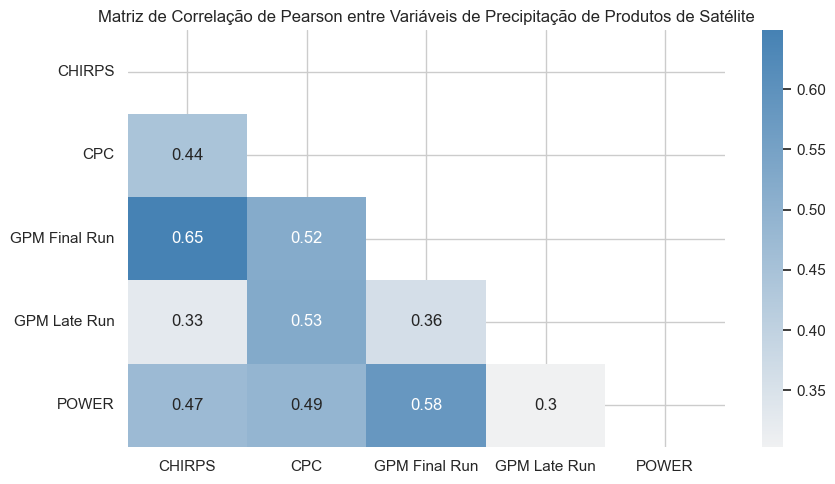

In [35]:
df_corr_produto = df_abt_base.loc[df_abt_base['vl_precipitacao_cpc']>=0,precipitacao_produtos_columns].corr() \
    .rename(
        columns={
            'vl_precipitacao_chirps':'CHIRPS',
            'vl_precipitacao_cpc':'CPC',
            'vl_precipitacao_gpm_final_run':'GPM Final Run',
            'vl_precipitacao_gpm_late_run':'GPM Late Run',
            'vl_precipitacao_power':'POWER'
        },
        index={
            'vl_precipitacao_chirps':'CHIRPS',
            'vl_precipitacao_cpc':'CPC',
            'vl_precipitacao_gpm_final_run':'GPM Final Run',
            'vl_precipitacao_gpm_late_run':'GPM Late Run',
            'vl_precipitacao_power':'POWER'
        }
    )

palette = sns.light_palette("steelblue", as_cmap=True)
mask = np.triu(np.ones_like(df_corr_produto, dtype=bool))

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    df_corr_produto,
    mask=mask,
    cmap=palette,
    annot=True)

ax.set_title(
    'Matriz de Correlação de Pearson entre Variáveis de Precipitação de Produtos de Satélite'
)

plt.tight_layout()
plt.show()

In [ ]:
df_corr_produto

,CHIRPS,CPC,GPM Final Run,GPM Late Run,POWER
CHIRPS,1.000000,0.001639,0.648766,0.327524,0.470991
CPC,0.001639,1.000000,-0.003433,-0.002094,-0.000511
GPM Final Run,0.648766,-0.003433,1.000000,0.360882,0.579134
GPM Late Run,0.327524,-0.002094,0.360882,1.000000,0.302352
POWER,0.470991,-0.000511,0.579134,0.302352,1.000000


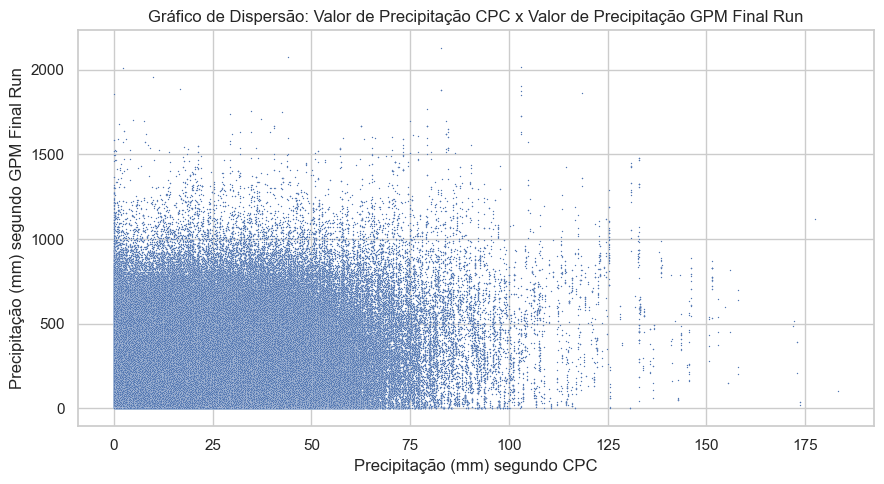

In [34]:
import numpy as np
from matplotlib.lines import Line2D


sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.light_palette("steelblue", as_cmap=True)

sns.scatterplot(
    data=df_abt_base.loc[df_abt_base['vl_precipitacao_cpc']>=0],
    x='vl_precipitacao_cpc',
    y='vl_precipitacao_gpm_final_run',
    s=1,
    ax=ax,
    legend=False
)

ax.set_title(
    'Gráfico de Dispersão: Valor de Precipitação CPC x '
    f'Valor de Precipitação GPM Final Run'
)
ax.set_xlabel('Precipitação (mm) segundo CPC')
ax.set_ylabel('Precipitação (mm) segundo GPM Final Run')

plt.tight_layout()
plt.show()

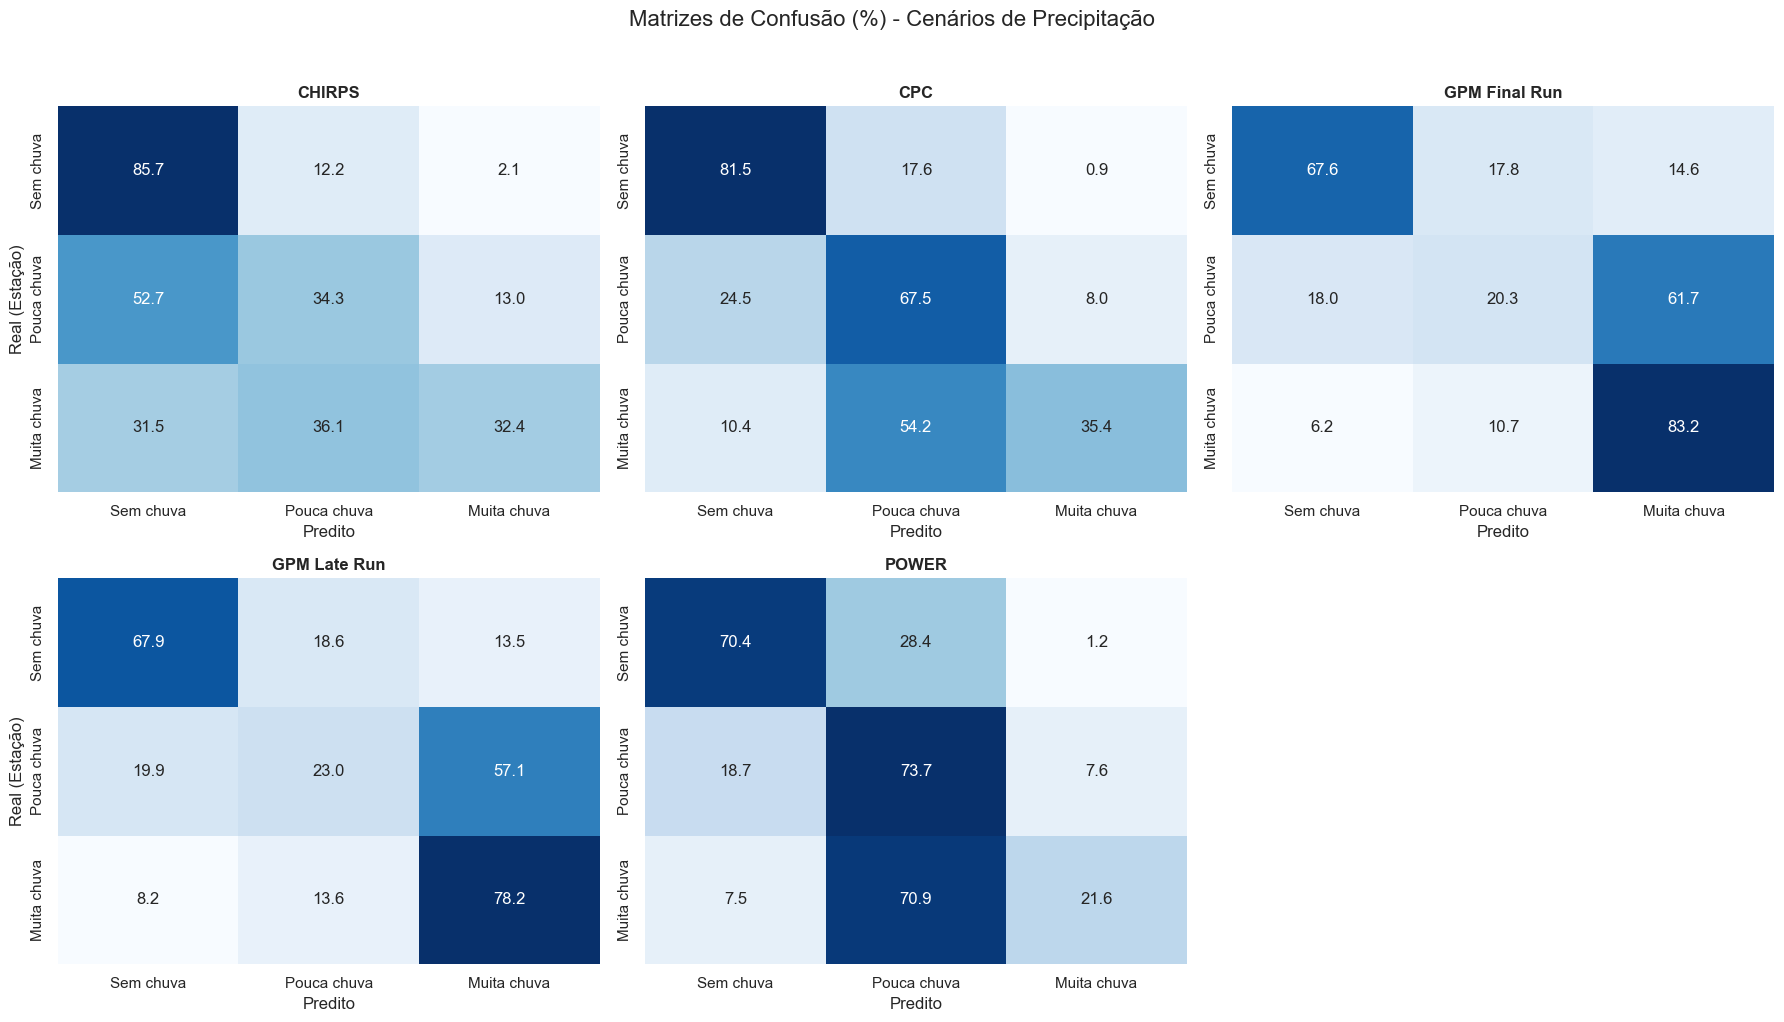

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

df_extremos = df_abt_base.copy()

# --- NOVO: Dicionário para mapear os nomes das colunas para os títulos amigáveis ---
nomes_produtos = {
    'vl_precipitacao_chirps': 'CHIRPS',
    'vl_precipitacao_gpm_final_run': 'GPM Final Run',
    'vl_precipitacao_cpc': 'CPC',
    'vl_precipitacao_gpm_late_run':'GPM Late Run',
    'vl_precipitacao_power':'POWER'
}
# ----------------------------------------------------------------------------------

# 1. Definir os intervalos e os nomes das categorias
bins = [-np.inf, 1, 20, np.inf]
categorias = ['Sem chuva', 'Pouca chuva', 'Muita chuva']

# Classificando a coluna real (Estação)
df_extremos['vl_precipitacao_classe'] = pd.cut(df_extremos['vl_precipitacao'], bins=bins, labels=categorias, right=False)

resultados = {}

for col in precipitacao_produtos_columns:
    
    # Classificando os dados preditos pelo produto atual
    df_extremos[col + '_classe'] = pd.cut(df_extremos[col], bins=bins, labels=categorias, right=False)
    
    # Filtrar as linhas que têm NaN no real ou na predição atual
    df_filtrado = df_extremos[['vl_precipitacao_classe', col + '_classe']].dropna()
    
    y_true_filtrado = df_filtrado['vl_precipitacao_classe']
    y_pred_filtrado = df_filtrado[col + '_classe']
    
    # Calcular a matriz com os dados limpos
    cm = confusion_matrix(y_true_filtrado, y_pred_filtrado, labels=categorias)
    resultados[col] = cm

# 2. Criar a figura com 2 linhas e 3 colunas (total de 6 subplots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (produto, cm) in enumerate(resultados.items()):
    ax = axes[i]
    
    # Normalizar por linha (cada linha soma 100%)
    soma_linhas = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(cm.astype(float), soma_linhas, out=np.zeros_like(cm, dtype=float), where=soma_linhas!=0) * 100
    
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=categorias,
        yticklabels=categorias,
        ax=ax,
        cbar=False
    )
    
    # --- NOVO: Buscar o nome amigável no dicionário. Se não achar, usa o nome da coluna original ---
    titulo_formatado = nomes_produtos.get(produto, produto)
    ax.set_title(f'{titulo_formatado}', fontsize=12, fontweight='bold')
    # ----------------------------------------------------------------------------------------------
    
    ax.set_xlabel('Predito')
    
    # Mostrar o label do eixo Y apenas nos gráficos da primeira coluna
    if i % 3 == 0:
        ax.set_ylabel('Real (Estação)')
    else:
        ax.set_ylabel('')

# O último espaço (índice 5) ficará vazio, então o apagamos
for j in range(len(resultados), len(axes)):
    fig.delaxes(axes[j])

# Título geral para a figura inteira
plt.suptitle('Matrizes de Confusão (%) - Cenários de Precipitação', y=1.02, fontsize=16)

plt.tight_layout()
plt.show()